Discharge analysis

In [4]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path


In [12]:
grdc_obs = pd.read_csv(
    '/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt',
    encoding='latin-1',
    sep=';',
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = 'date'
grdc_obs.columns = ['Observations from GRDC']


In [13]:
grdc_obs

,Observations from GRDC
date,
1930-12-07,415.0
1930-12-08,388.0
1930-12-09,378.0
1930-12-10,391.0
1930-12-11,388.0
...,...
2020-12-27,568.0
2020-12-28,663.0
2020-12-29,698.0


In [5]:
def exceedance_probability(Q):
    """Sort and rank discharge to compute exceedance probability."""
    Q_sorted = np.sort(Q.dropna())[::-1]  # sort descending
    n = len(Q_sorted)
    prob = np.arange(1, n + 1) / (n + 1)  # Weibull plotting position
    return prob, Q_sorted

In [14]:
q = grdc_obs['Observations from GRDC']
prob, Q_sorted = exceedance_probability(q)

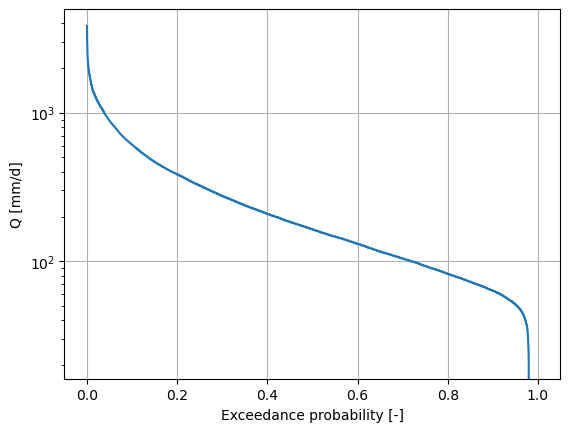

In [15]:
plt.plot(prob, Q_sorted)
plt.yscale('log')
plt.ylabel('Q [mm/d]')
plt.xlabel('Exceedance probability [-]')
plt.grid()